In [2]:
# from google.colab import drive
# import os
# drive.mount('/content/drive')

# if not os.path.exists('/content/ptbxl'): # Replace with the actual folder name inside the zip
#     !cp "/content/drive/MyDrive/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.zip" /content/ptbxl.zip
#     !unzip -oq /content/ptbxl.zip -d /content/
#     print("Extraction complete.")
# else:
#     print("Dataset already exists, skipping extraction.")

In [3]:
!pip -q install wfdb

In [55]:
import ast
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import wfdb

import torch
import torch.nn as nn

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import copy

import neurokit2 as nk

In [5]:
from google.colab import drive
from pathlib import Path

In [ ]:
# drive.mount("/content/drive")

PTBXL_ROOT = Path("/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1")
METADATA_CSV = PTBXL_ROOT / "ptbxl_database.csv"
SCP_CSV = PTBXL_ROOT / "scp_statements.csv"

assert METADATA_CSV.exists(), METADATA_CSV
assert SCP_CSV.exists(), SCP_CSV

### Load data

In [ ]:
df = pd.read_csv(METADATA_CSV)
scp_df = pd.read_csv(SCP_CSV, index_col=0)

df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

print(df.shape)
df.head(2)

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


In [8]:
scp_df

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
...,...,...,...,...,...,...,...,...,...,...,...,...
BIGU,"bigeminal pattern (unknown origin, SV or Ventr...",NaN,NaN,1.0,NaN,NaN,Statements related to ectopic rhythm abnormali...,"bigeminal pattern (unknown origin, SV or Ventr...",NaN,NaN,NaN,NaN
AFLT,atrial flutter,NaN,NaN,1.0,NaN,NaN,Statements related to impulse formation (abnor...,atrial flutter,51.0,MDC_ECG_RHY_ATR_FLUT,NaN,NaN
SVTAC,supraventricular tachycardia,NaN,NaN,1.0,NaN,NaN,Statements related to impulse formation (abnor...,supraventricular tachycardia,55.0,MDC_ECG_RHY_SV_TACHY,NaN,D3-31290
PSVT,paroxysmal supraventricular tachycardia,NaN,NaN,1.0,NaN,NaN,Statements related to impulse formation (abnor...,paroxysmal supraventricular tachycardia,NaN,MDC_ECG_RHY_SV_TACHY_PAROX,NaN,NaN


In [9]:
#map each SCP statement to diagnostic superclass
#then collect the superclasses present for each record
#mark a record as MI-positive if "MI" is among those diagnostic superclasses

diagnostic_map = scp_df[scp_df["diagnostic"] == 1]["diagnostic_class"].to_dict()

def get_diagnostic_superclasses(scp_codes_dict):
    classes = set()
    for code in scp_codes_dict.keys():
        if code in diagnostic_map:
            cls = diagnostic_map[code]
            if pd.notna(cls):
                classes.add(cls)
    return sorted(classes)

df["diagnostic_superclasses"] = df["scp_codes"].apply(get_diagnostic_superclasses)
df["label_mi"] = df["diagnostic_superclasses"].apply(lambda xs: int("MI" in xs))

df[["ecg_id", "diagnostic_superclasses", "label_mi"]].head(10)

,ecg_id,diagnostic_superclasses,label_mi
0,1,[NORM],0
1,2,[NORM],0
2,3,[NORM],0
3,4,[NORM],0
4,5,[NORM],0
5,6,[NORM],0
6,7,[NORM],0
7,8,[MI],1
8,9,[NORM],0
9,10,[NORM],0


In [10]:
df["label_mi"].value_counts(dropna=False)

label_mi
0    16330
1     5469
Name: count, dtype: int64

### Create fold split

In [11]:
train_df = df[df["strat_fold"].between(1, 8)].copy()
val_df   = df[df["strat_fold"] == 9].copy()
test_df  = df[df["strat_fold"] == 10].copy()

In [12]:
print(len(train_df), len(val_df), len(test_df))
print(train_df["label_mi"].mean(), val_df["label_mi"].mean(), test_df["label_mi"].mean())

17418 2183 2198
0.2514065908829946 0.24736601007787448 0.2502274795268426


In [13]:
[c for c in df.columns if "filename" in c.lower()]

['filename_lr', 'filename_hr']

### Define waveform loader

In [14]:
def load_signal_100hz(row, root=PTBXL_ROOT):
    record_path = root / row["filename_lr"]  # low-rate = 100 Hz
    signal, meta = wfdb.rdsamp(str(record_path))
    # wfdb returns shape [1000, 12] for PTB-XL 100 Hz records
    signal = signal.astype(np.float32).T      # -> [12, 1000]
    return signal

In [15]:
x0 = load_signal_100hz(train_df.iloc[0])
print(x0.shape, x0.dtype, np.min(x0), np.max(x0))

(12, 1000) float32 -1.377 0.706


### Metadata preprocessing
We preprocess numerical metadata (specifically age, height, weight) by doing mean imputation and by transforming these features to a range of [0,1] via MinMaxScaler. Both the mean of features and scaling transformation are computed using the training set, and applied to all train/val/test sets.

We preprocess the categorical sex metadata by mapping each male', 'female', 'missing' category to a numerical label (0 or 1)

In [16]:
NUM_COLS = ["age", "height", "weight"]
CAT_COL = "sex"

train_num = train_df[NUM_COLS].copy()
val_num   = val_df[NUM_COLS].copy()
test_num  = test_df[NUM_COLS].copy()

num_means = train_num.mean()

train_num = train_num.fillna(num_means)
val_num   = val_num.fillna(num_means)
test_num  = test_num.fillna(num_means)

scaler = MinMaxScaler()
train_num_scaled = scaler.fit_transform(train_num)
val_num_scaled   = scaler.transform(val_num)
test_num_scaled  = scaler.transform(test_num)

le = LabelEncoder()
train_sex = le.fit_transform(train_df[CAT_COL].fillna("missing"))
val_sex   = le.transform(val_df[CAT_COL].fillna("missing"))
test_sex  = le.transform(test_df[CAT_COL].fillna("missing"))

In [17]:
for split_df, num_scaled, sex_encoded in [
    (train_df, train_num_scaled, train_sex),
    (val_df, val_num_scaled, val_sex),
    (test_df, test_num_scaled, test_sex),
]:
    split_df["age_scaled"] = num_scaled[:, 0]
    split_df["height_scaled"] = num_scaled[:, 1]
    split_df["weight_scaled"] = num_scaled[:, 2]
    split_df["sex_encoded"] = sex_encoded

### Define the PyTorch Dataset

In [18]:
class PTBXLBinaryMIDataset(Dataset):
    def __init__(self, split_df, root=PTBXL_ROOT):
        self.df = split_df.reset_index(drop=True).copy()
        self.root = Path(root)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        signal = load_signal_100hz(row, root=self.root)  # [12, 1000]
        signal = torch.tensor(signal, dtype=torch.float32)

        meta_num = torch.tensor(
            [row["age_scaled"], row["height_scaled"], row["weight_scaled"]],
            dtype=torch.float32
        )

        meta_cat = torch.tensor(row["sex_encoded"], dtype=torch.long)

        label = torch.tensor(row["label_mi"], dtype=torch.float32)

        return {
            "signal": signal,
            "meta_num": meta_num,
            "meta_cat": meta_cat,
            "label": label,
            "ecg_id": int(row["ecg_id"]),
        }

In [19]:
train_ds = PTBXLBinaryMIDataset(train_df)
val_ds   = PTBXLBinaryMIDataset(val_df)
test_ds  = PTBXLBinaryMIDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [20]:
batch = next(iter(train_loader))

print("signal:", batch["signal"].shape)    # expected [B, 12, 1000]
print("meta_num:", batch["meta_num"].shape)  # expected [B, 3]
print("meta_cat:", batch["meta_cat"].shape)  # expected [B]
print("label:", batch["label"].shape)        # expected [B]
print("example ecg_id:", batch["ecg_id"][:5])

signal: torch.Size([32, 12, 1000])
meta_num: torch.Size([32, 3])
meta_cat: torch.Size([32])
label: torch.Size([32])
example ecg_id: tensor([14135, 15557,  3796, 18170,  3325])


### GRU baseline

In [21]:
class GRUBinaryMIClassifier(nn.Module):
    def __init__(
        self,
        num_signal_channels=12,
        num_numeric_meta=3,
        sex_num_classes=3,
        sex_emb_dim=4,
        gru_hidden_dim=128,
        gru_num_layers=2,
        mlp_hidden_dim=128,
        dropout=0.3,
    ):
        super().__init__()

        self.sex_embedding = nn.Embedding(
            num_embeddings=sex_num_classes,
            embedding_dim=sex_emb_dim
        )

        self.gru = nn.GRU(
            input_size=num_signal_channels,
            hidden_size=gru_hidden_dim,
            num_layers=gru_num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_num_layers > 1 else 0.0,
        )

        pooled_dim = 2 * gru_hidden_dim * 2   # avg pool + max pool
        meta_dim = num_numeric_meta + sex_emb_dim
        fusion_dim = pooled_dim + meta_dim

        self.fc1 = nn.Linear(fusion_dim, mlp_hidden_dim)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm1d(mlp_hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(mlp_hidden_dim, 1)

    def forward(self, signal, meta_num, meta_cat):
        # signal: [B, 12, 1000] -> [B, 1000, 12]
        x = signal.transpose(1, 2)

        # GRU output: [B, T, 2H]
        x, _ = self.gru(x)

        avg_pool = x.mean(dim=1)          # [B, 2H]
        max_pool = x.max(dim=1).values    # [B, 2H]
        signal_feat = torch.cat([avg_pool, max_pool], dim=1)

        sex_emb = self.sex_embedding(meta_cat)   # [B, sex_emb_dim]
        meta_feat = torch.cat([meta_num, sex_emb], dim=1)

        feat = torch.cat([signal_feat, meta_feat], dim=1)

        x = self.fc1(feat)
        x = self.relu(x)
        x = self.bn(x)
        x = self.dropout(x)
        logits = self.out(x).squeeze(1)

        return logits

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sex_num_classes = int(
    train_df["sex_encoded"].max()+ 1
)

model = GRUBinaryMIClassifier(
    num_signal_channels=12,
    num_numeric_meta=3,
    sex_num_classes=sex_num_classes,
    sex_emb_dim=4,
    gru_hidden_dim=128,
    gru_num_layers=2,
    mlp_hidden_dim=128,
    dropout=0.3,
).to(device)

print(device)

cuda


Run for one epoch

In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        signal = batch["signal"].to(device)
        meta_num = batch["meta_num"].to(device)
        meta_cat = batch["meta_cat"].to(device)
        label = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(signal, meta_num, meta_cat)
        loss = criterion(logits, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * signal.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in loader:
        signal = batch["signal"].to(device)
        meta_num = batch["meta_num"].to(device)
        meta_cat = batch["meta_cat"].to(device)
        label = batch["label"].to(device)

        logits = model(signal, meta_num, meta_cat)
        loss = criterion(logits, label)

        running_loss += loss.item() * signal.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(label.detach().cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-all_logits))
    auc = roc_auc_score(all_labels, probs)

    return running_loss / len(loader.dataset), auc


In [ ]:
# train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
# val_loss, val_auc = evaluate(model, val_loader, criterion, device)

# print(f"train_loss={train_loss:.4f}")
# print(f"val_loss={val_loss:.4f}, val_auc={val_auc:.4f}")

Run for 5 epochs

epoch=1/5 train_loss=0.4299 val_loss=0.3655 val_auc=0.8792
epoch=2/5 train_loss=0.3327 val_loss=0.3226 val_auc=0.9107
epoch=3/5 train_loss=0.3004 val_loss=0.3444 val_auc=0.9056
epoch=4/5 train_loss=0.2871 val_loss=0.3128 val_auc=0.9242
epoch=5/5 train_loss=0.2791 val_loss=0.3082 val_auc=0.9222

Best val AUC: 0.9242 at epoch 4


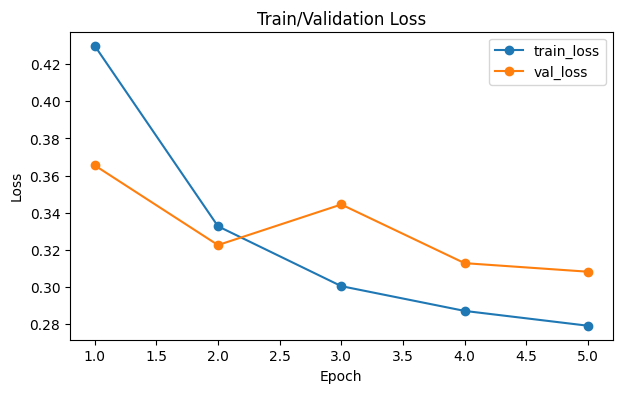

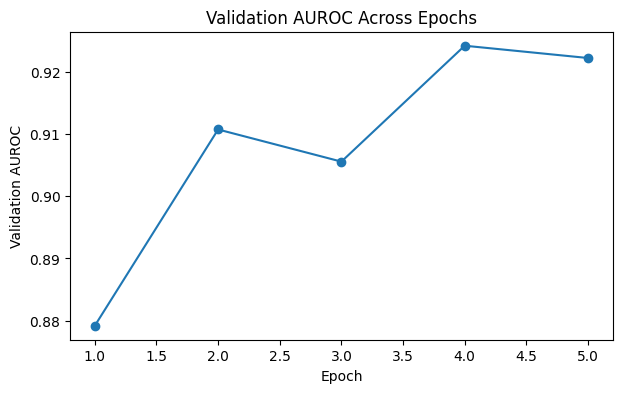

Validation AUCs: [0.8792 0.9107 0.9056 0.9242 0.9222]
AUC range: 0.045
AUC std: 0.0162
Reloaded best model from epoch 4.


In [40]:
# Train for 5 epochs, log train/val curves, and track AUC stability

num_epochs = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

best_state = None
best_val_auc = -float("inf")
best_epoch = -1

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"epoch={epoch+1}/{num_epochs} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_auc={val_auc:.4f}"
    )

print(f"\nBest val AUC: {best_val_auc:.4f} at epoch {best_epoch}")

# Plot train/val loss curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), history["train_loss"], marker="o", label="train_loss")
plt.plot(range(1, num_epochs + 1), history["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Validation Loss")
plt.legend()
plt.show()

# Plot validation AUC curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), history["val_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation AUROC")
plt.title("Validation AUROC Across Epochs")
plt.show()

# Simple AUC stability summary
val_auc_array = np.array(history["val_auc"])
print("Validation AUCs:", np.round(val_auc_array, 4))
print("AUC range:", round(val_auc_array.max() - val_auc_array.min(), 4))
print("AUC std:", round(val_auc_array.std(), 4))

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Reloaded best model from epoch {best_epoch}.")

In [41]:
test_loss, test_auc = evaluate(model, test_loader, criterion, device)
print(f"test_loss={test_loss:.4f}, test_auc={test_auc:.4f}")

test_loss=0.3221, test_auc=0.9154


### Sex comparison

In [42]:
female_test_df = test_df[test_df["sex_encoded"] == 1].copy()
male_test_df   = test_df[test_df["sex_encoded"] == 0].copy()

print("female_test_df:", len(female_test_df))
print("male_test_df:", len(male_test_df))

print("Female MI prevalence:", female_test_df["label_mi"].mean())
print("Male MI prevalence:", male_test_df["label_mi"].mean())

female_test_df: 1066
male_test_df: 1132
Female MI prevalence: 0.2373358348968105
Male MI prevalence: 0.2623674911660777


In [43]:
female_test_ds = PTBXLBinaryMIDataset(female_test_df)
male_test_ds   = PTBXLBinaryMIDataset(male_test_df)

female_test_loader = DataLoader(female_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
male_test_loader   = DataLoader(male_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [44]:
female_test_ds = PTBXLBinaryMIDataset(female_test_df)
male_test_ds   = PTBXLBinaryMIDataset(male_test_df)

female_test_loader = DataLoader(female_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
male_test_loader   = DataLoader(male_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [45]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate_with_pr_auc(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits = []
    all_labels = []

    for batch in loader:
        signal = batch["signal"].to(device)
        meta_num = batch["meta_num"].to(device)
        meta_cat = batch["meta_cat"].to(device)
        label = batch["label"].to(device)

        logits = model(signal, meta_num, meta_cat)
        # loss = criterion(logits, label)

        # running_loss += loss.item() * signal.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(label.detach().cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-all_logits))

    return {
        # "loss": running_loss / len(loader.dataset),
        "n": int(len(all_labels)),
        "prevalence": float(all_labels.mean()),
        "auroc": float(roc_auc_score(all_labels, probs)),
        "pr_auc": float(average_precision_score(all_labels, probs)),
    }

In [46]:
overall_metrics = evaluate_with_pr_auc(model, test_loader, criterion, device)
female_metrics  = evaluate_with_pr_auc(model, female_test_loader, criterion, device)
male_metrics    = evaluate_with_pr_auc(model, male_test_loader, criterion, device)

results_now = pd.DataFrame([
    {"split": "overall_test", **overall_metrics},
    {"split": "female_test", **female_metrics},
    {"split": "male_test", **male_metrics},
])

results_now

,split,n,prevalence,auroc,pr_auc
0,overall_test,2198,0.250227,0.915352,0.810242
1,female_test,1066,0.237336,0.903267,0.779308
2,male_test,1132,0.262367,0.925849,0.835437


In [47]:
print(f"Female AUROC: {female_metrics['auroc']:.4f}")
print(f"Male AUROC:   {male_metrics['auroc']:.4f}")
print(f"Male - Female AUROC gap: {male_metrics['auroc'] - female_metrics['auroc']:+.4f}")

print()

print(f"Female PR AUC: {female_metrics['pr_auc']:.4f}")
print(f"Male PR AUC:   {male_metrics['pr_auc']:.4f}")
print(f"Male - Female PR AUC gap: {male_metrics['pr_auc'] - female_metrics['pr_auc']:+.4f}")

Female AUROC: 0.9033
Male AUROC:   0.9258
Male - Female AUROC gap: +0.0226

Female PR AUC: 0.7793
Male PR AUC:   0.8354
Male - Female PR AUC gap: +0.0561


### Testing sex difference in limited data regime

In [48]:
def make_stratified_fraction(df, frac=0.5, group_cols=("sex_encoded", "label_mi"), seed=42):
    rng = np.random.default_rng(seed)
    parts = []

    for _, g in df.groupby(list(group_cols), dropna=False):
        n = len(g)
        k = max(1, int(round(frac * n)))
        idx = rng.choice(g.index.to_numpy(), size=min(k, n), replace=False)
        parts.append(df.loc[idx])

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_df_50 = make_stratified_fraction(
    train_df,
    frac=0.5,
    group_cols=("sex_encoded", "label_mi"),
    seed=123,
)

print("Original train size:", len(train_df))
print("50% train size:", len(train_df_50))

print("\nOriginal train sex x label:")
print(pd.crosstab(train_df["sex_encoded"], train_df["label_mi"], normalize="index"))

print("\n50% train sex x label:")
print(pd.crosstab(train_df_50["sex_encoded"], train_df_50["label_mi"], normalize="index"))

Original train size: 17418
50% train size: 8709

Original train sex x label:
label_mi            0         1
sex_encoded                    
0            0.691935  0.308065
1            0.810421  0.189579

50% train sex x label:
label_mi            0         1
sex_encoded                    
0            0.691901  0.308099
1            0.810324  0.189676


In [49]:
train_ds_50 = PTBXLBinaryMIDataset(train_df_50)

train_loader_50 = DataLoader(
    train_ds_50,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [50]:
sex_num_classes = int(train_df["sex_encoded"].max() + 1)

model_50 = GRUBinaryMIClassifier(
    num_signal_channels=12,
    num_numeric_meta=3,
    sex_num_classes=sex_num_classes,
    sex_emb_dim=4,
    gru_hidden_dim=128,
    gru_num_layers=2,
    mlp_hidden_dim=128,
    dropout=0.3,
).to(device)

criterion_50 = nn.BCEWithLogitsLoss()
optimizer_50 = torch.optim.AdamW(model_50.parameters(), lr=1e-3, weight_decay=1e-4)

In [51]:
num_epochs = 5

history_50 = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

best_state_50 = None
best_val_auc_50 = -float("inf")
best_epoch_50 = -1

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model_50, train_loader_50, optimizer_50, criterion_50, device)
    val_loss, val_auc = evaluate(model_50, val_loader, criterion_50, device)

    history_50["train_loss"].append(train_loss)
    history_50["val_loss"].append(val_loss)
    history_50["val_auc"].append(val_auc)

    if val_auc > best_val_auc_50:
        best_val_auc_50 = val_auc
        best_epoch_50 = epoch + 1
        best_state_50 = copy.deepcopy(model_50.state_dict())

    print(
        f"epoch={epoch+1}/{num_epochs} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f} "
        f"val_auc={val_auc:.4f}"
    )

print(f"\nBest val AUC (50% train): {best_val_auc_50:.4f} at epoch {best_epoch_50}")

if best_state_50 is not None:
    model_50.load_state_dict(best_state_50)
    print(f"Reloaded best 50% model from epoch {best_epoch_50}.")

epoch=1/5 train_loss=0.4859 val_loss=0.4000 val_auc=0.8544
epoch=2/5 train_loss=0.3784 val_loss=0.3706 val_auc=0.8804
epoch=3/5 train_loss=0.3361 val_loss=0.3576 val_auc=0.8947
epoch=4/5 train_loss=0.3068 val_loss=0.3487 val_auc=0.9043
epoch=5/5 train_loss=0.2920 val_loss=0.3330 val_auc=0.9050

Best val AUC (50% train): 0.9050 at epoch 5
Reloaded best 50% model from epoch 5.


In [52]:
overall_metrics_50 = evaluate_with_pr_auc(model_50, test_loader, criterion_50, device)
female_metrics_50  = evaluate_with_pr_auc(model_50, female_test_loader, criterion_50, device)
male_metrics_50    = evaluate_with_pr_auc(model_50, male_test_loader, criterion_50, device)

results_50 = pd.DataFrame([
    {"split": "overall_test", **overall_metrics_50},
    {"split": "female_test", **female_metrics_50},
    {"split": "male_test", **male_metrics_50},
])

results_50

,split,n,prevalence,auroc,pr_auc
0,overall_test,2198,0.250227,0.899545,0.777712
1,female_test,1066,0.237336,0.879862,0.724814
2,male_test,1132,0.262367,0.918748,0.820443


In [53]:
print(f"Female AUROC (50% train): {female_metrics_50['auroc']:.4f}")
print(f"Male AUROC   (50% train): {male_metrics_50['auroc']:.4f}")
print(f"Male - Female AUROC gap: {male_metrics_50['auroc'] - female_metrics_50['auroc']:+.4f}")

print()

print(f"Female PR AUC (50% train): {female_metrics_50['pr_auc']:.4f}")
print(f"Male PR AUC   (50% train): {male_metrics_50['pr_auc']:.4f}")
print(f"Male - Female PR AUC gap: {male_metrics_50['pr_auc'] - female_metrics_50['pr_auc']:+.4f}")

Female AUROC (50% train): 0.8799
Male AUROC   (50% train): 0.9187
Male - Female AUROC gap: +0.0389

Female PR AUC (50% train): 0.7248
Male PR AUC   (50% train): 0.8204
Male - Female PR AUC gap: +0.0956


### Synthetic ecg generation using NeuroKit2

In [54]:
!pip -q install neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 141.7 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
ecg_12 = nk.ecg_simulate(
    duration=10,
    sampling_rate=100,
    heart_rate=70,
    method="multileads",
    noise=0.01,
    random_state=42,
)

ecg_12 = np.asarray(ecg_12)

print("shape:", ecg_12.shape)
print("dtype:", ecg_12.dtype)

shape: (1000, 12)
dtype: float64


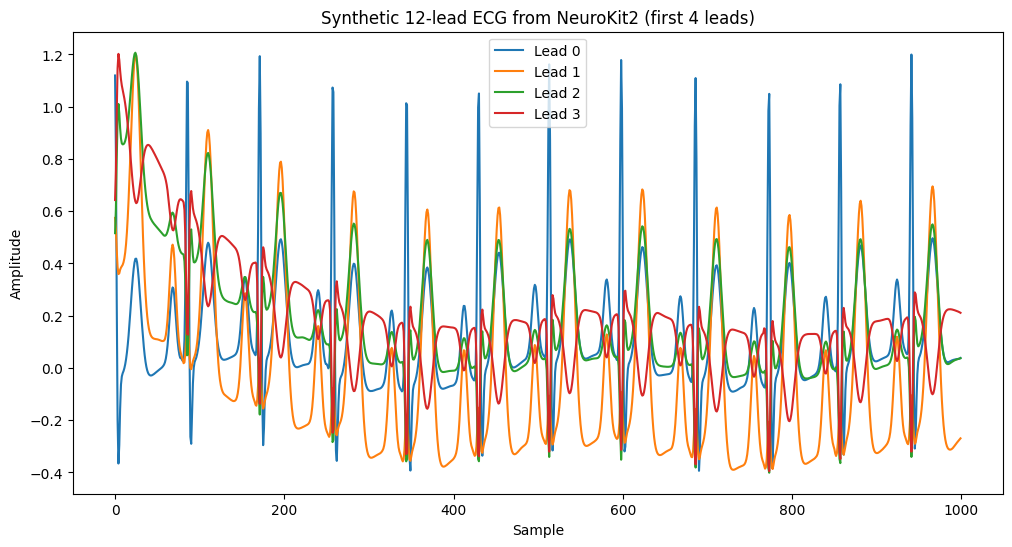

In [57]:
ecg_12 = ecg_12.astype(np.float32)

plt.figure(figsize=(12, 6))
for lead_idx in range(4):
    plt.plot(ecg_12[:, lead_idx], label=f"Lead {lead_idx}")
plt.title("Synthetic 12-lead ECG from NeuroKit2 (first 4 leads)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

Number of R-peaks: 11
First few R-peaks: [ 85 171 257 344 430 513 598 686 773 857]


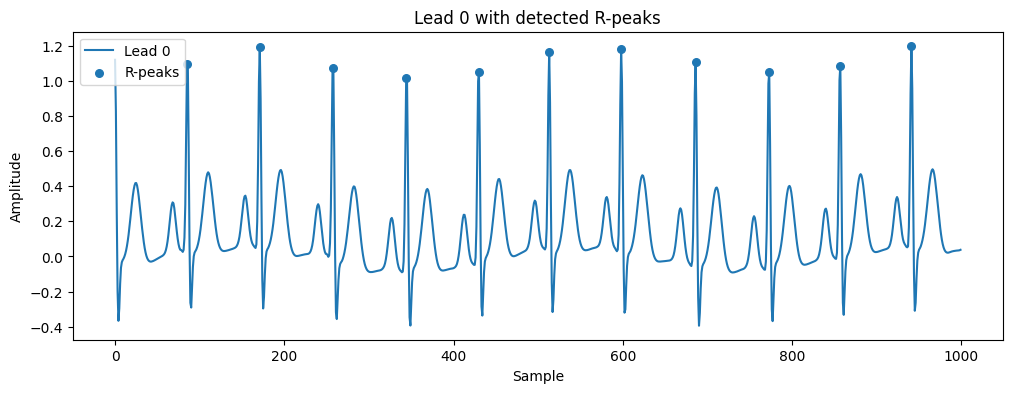

In [58]:
lead0 = ecg_12[:, 0]

signals, info = nk.ecg_peaks(lead0, sampling_rate=100)
rpeaks = info["ECG_R_Peaks"]

print("Number of R-peaks:", len(rpeaks))
print("First few R-peaks:", rpeaks[:10])

plt.figure(figsize=(12, 4))
plt.plot(lead0, label="Lead 0")
plt.scatter(rpeaks, lead0[rpeaks], label="R-peaks", s=30)
plt.title("Lead 0 with detected R-peaks")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [59]:
def apply_minimal_mi_morphology(signal_2d, rpeaks, sampling_rate=100):
    """
    signal_2d: [T, 12]
    rpeaks: array of R-peak sample indices
    returns a modified copy with simple MI-like morphology
    """
    x = signal_2d.copy()
    T, L = x.shape

    # Use a few leads as 'affected' leads for now
    affected_leads = [0, 1, 2, 3]

    for rp in rpeaks:
        # Q region: slightly before R
        q_start = max(rp - int(0.04 * sampling_rate), 0)
        q_end   = max(rp - int(0.01 * sampling_rate), 0)

        # ST region: shortly after R
        st_start = min(rp + int(0.02 * sampling_rate), T)
        st_end   = min(rp + int(0.10 * sampling_rate), T)

        # T region: later after R
        t_start = min(rp + int(0.12 * sampling_rate), T)
        t_end   = min(rp + int(0.28 * sampling_rate), T)

        for lead in affected_leads:
            # 1) Deepen Q-wave by pushing it down a bit
            if q_end > q_start:
                x[q_start:q_end, lead] -= 0.10

            # 2) Elevate ST segment
            if st_end > st_start:
                x[st_start:st_end, lead] += 0.15

            # 3) Invert and shrink the T-wave region
            if t_end > t_start:
                x[t_start:t_end, lead] = -0.7 * x[t_start:t_end, lead]

    return x

In [60]:
normal_ecg = ecg_12.copy()
mi_ecg = apply_minimal_mi_morphology(ecg_12, rpeaks, sampling_rate=100)

print(normal_ecg.shape, mi_ecg.shape)

(1000, 12) (1000, 12)


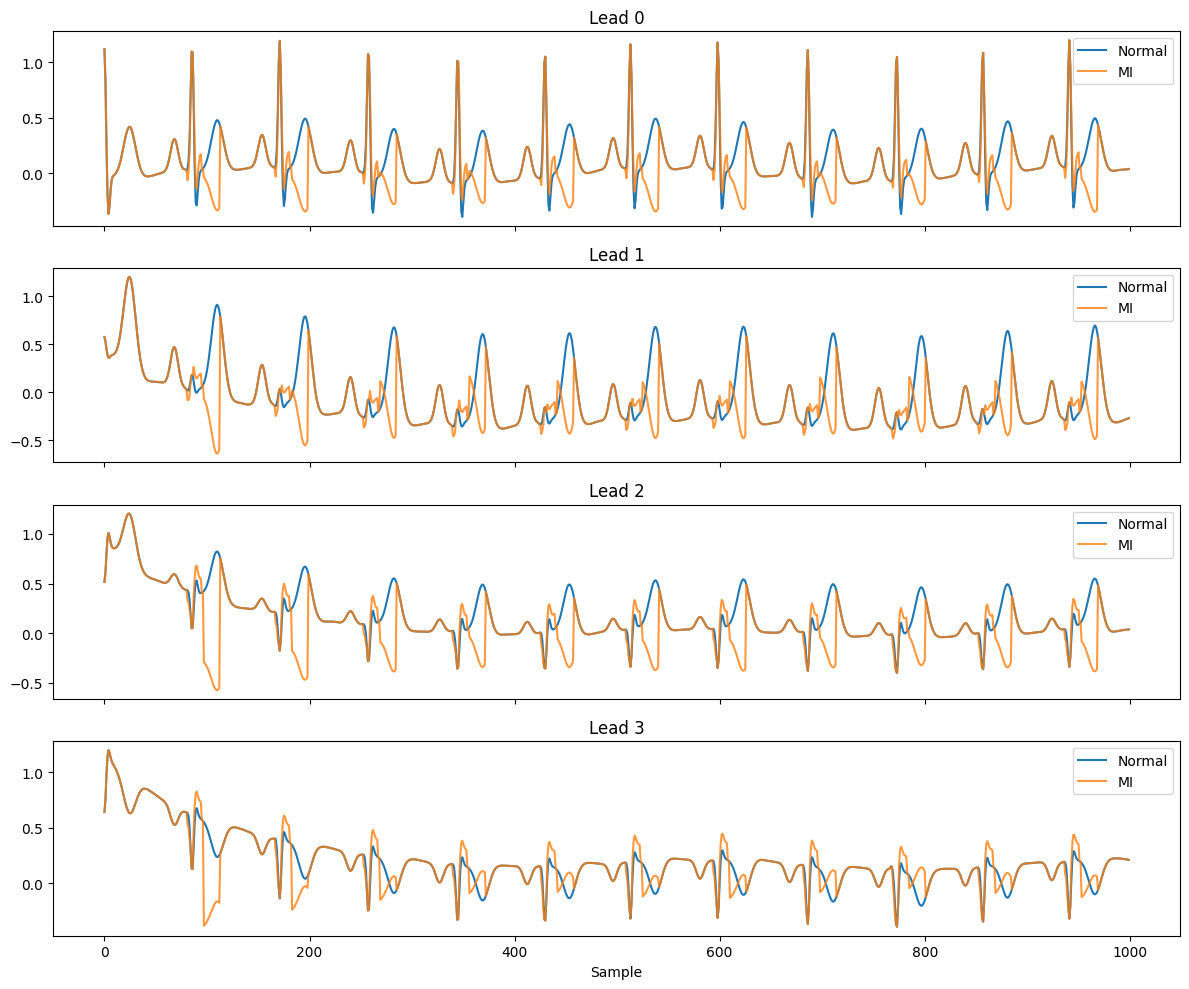

In [61]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for ax_idx, lead_idx in enumerate([0, 1, 2, 3]):
    axes[ax_idx].plot(normal_ecg[:, lead_idx], label="Normal")
    axes[ax_idx].plot(mi_ecg[:, lead_idx], label="MI", alpha=0.8)
    axes[ax_idx].set_title(f"Lead {lead_idx}")
    axes[ax_idx].legend()

plt.xlabel("Sample")
plt.tight_layout()
plt.show()

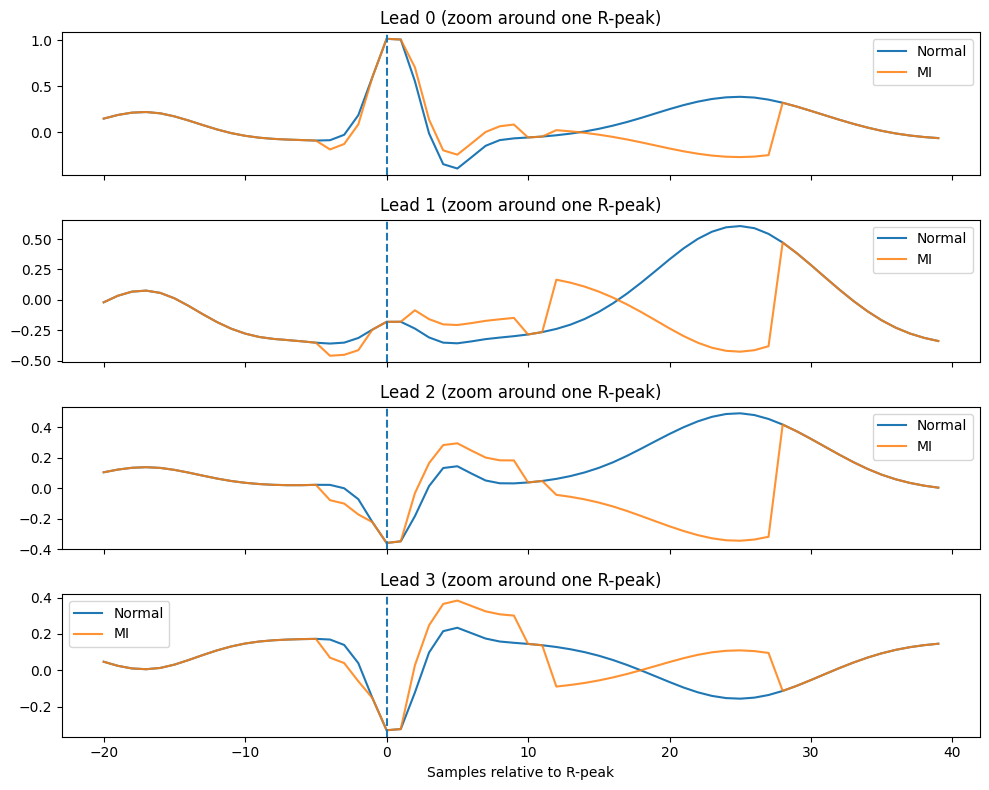

In [62]:
# Pick one beat to inspect
rp = rpeaks[3]   # you can change the index later

window_left = 20   # samples before R
window_right = 40  # samples after R

start = max(rp - window_left, 0)
end = min(rp + window_right, normal_ecg.shape[0])

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for ax_idx, lead_idx in enumerate([0, 1, 2, 3]):
    axes[ax_idx].plot(
        np.arange(start, end) - rp,
        normal_ecg[start:end, lead_idx],
        label="Normal"
    )
    axes[ax_idx].plot(
        np.arange(start, end) - rp,
        mi_ecg[start:end, lead_idx],
        label="MI",
        alpha=0.85
    )
    axes[ax_idx].axvline(0, linestyle="--")
    axes[ax_idx].set_title(f"Lead {lead_idx} (zoom around one R-peak)")
    axes[ax_idx].legend()

plt.xlabel("Samples relative to R-peak")
plt.tight_layout()
plt.show()

In [ ]:
def generate_synthetic_sample(label="normal", sampling_rate=100, duration=10, seed=None):
    rng = np.random.default_rng(seed)
    
    # Small variation in heart rate
    heart_rate = float(rng.uniform(60, 85))
    
    ecg = nk.ecg_simulate(
        duration=duration,
        sampling_rate=sampling_rate,
        heart_rate=heart_rate,
        method="multileads",
        noise=0.01,
        random_state=seed,
    )
    ecg = np.asarray(ecg, dtype=np.float32)

    # Detect R-peaks on lead 0
    lead0 = ecg[:, 0]
    _, info = nk.ecg_peaks(lead0, sampling_rate=sampling_rate)
    rpeaks = info["ECG_R_Peaks"]

    # Apply MI morphology only for MI class
    if label == "mi":
        ecg = apply_minimal_mi_morphology(ecg, rpeaks, sampling_rate=sampling_rate)

    return ecg